In [1]:
load('quandles-alpha.sage')

In [2]:
def plot_the_link(pd_example):
    pd = [list(t) for t in pd_example]
    L = Link(pd)
    print("Link:", L)
    print("Components:", L.number_of_components())
    G = L.plot()
    show(G)
def analyze_the_knot(pd_code):
    K = Knot(pd_code)
    arcs = K.arcs()
    crossings = K.dt_code()
    crossing_signs = []
    arc_crossings = []
    over_arcs = []
    under_arcs = []
    under_exit = []
    n = 0
    for i in crossings:
        crossing_signs.append(1)
        for j in pd_code:
            if i > 0:
                i = j[3]
                crossing_signs[n]=1
            if i < 0:
                i = j[3]
                crossing_signs[n]=-1
        n +=1
    for i in pd_code: 
        n = 1
        for j in arcs:
            if i[0] in j:
                under_arcs.append(n)
            if i[1] in j:
                over_arcs.append(n)
            if i[2] in j:
                under_exit.append(n)
            n += 1
    for i in range(len(pd_code)):   
        element = [over_arcs[i],under_arcs[i],under_exit[i]]
        arc_crossings.append(element)
    plot_the_link(pd_code)
    print("original pd code is", pd_code)
    print("arcs are ", arcs)
    print("crossing signs are ", crossing_signs)
    print("over,under entering, under existing arcs at crossings are ", arc_crossings)
    return(arcs, crossing_signs, arc_crossings)

Link: Link with 1 component represented by 3 crossings
Components: 1


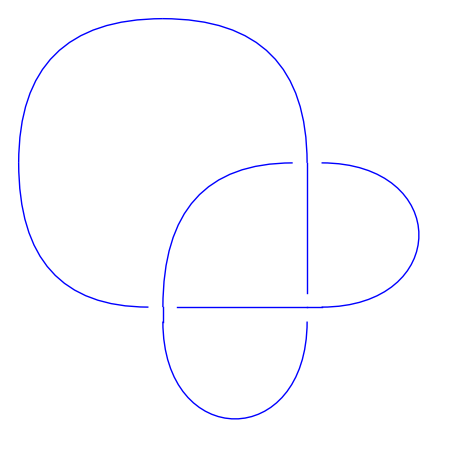

original pd code is [(1, 5, 2, 4), (5, 3, 6, 2), (3, 1, 4, 6)]
arcs are  [[6, 1], [2, 3], [4, 5]]
crossing signs are  [1, 1, 1]
over,under entering, under existing arcs at crossings are  [[3, 1, 2], [2, 3, 1], [1, 2, 3]]


In [3]:
pd_example = [(1, 5, 2, 4),                            # Example PD tuple list (trefoil-like example)
              (5, 3, 6, 2),
              (3, 1, 4, 6)]

#kinfo = analyze_pd_sage_debug(pd_example, debug=True)
# SageMath: plot a knot/link from PD code
# Sage usually accepts PD as a list of 4-lists; convert if needed:

arcs, crossing_signs, arc_crossings = analyze_the_knot(pd_example)

In [4]:
# -----------------------------
# Generator-level elimination -> then matrix substitution -> final Groebner
# Requires: your quandleElement class loaded in the session
# -----------------------------
class SymGen:
    """Symbolic generator (leaf) representing a generator g<id>."""
    def __init__(self, name):
        self.name = str(name)
    def __repr__(self):
        return self.name
    def quandleUnder(self, other):
        return SymOp(self, other)
    def variables(self):
        return {self.name}
    def substitute(self, mapping):
        # mapping: name -> SymExpr (or leave as-is)
        return mapping.get(self.name, self)

class SymOp:
    """Binary operation node representing (left) ▷ (right)."""
    def __init__(self, left, right):
        self.left = left
        self.right = right
    def __repr__(self):
        return f"({self.left} ▷ {self.right})"
    def variables(self):
        return set().union(*[ getattr(self.left, 'variables')() if callable(getattr(self.left,'variables',None)) else self.left.variables(),
                              getattr(self.right, 'variables')() if callable(getattr(self.right,'variables',None)) else self.right.variables() ])
    def substitute(self, mapping):
        L = self.left.substitute(mapping) if hasattr(self.left,'substitute') else self.left
        R = self.right.substitute(mapping) if hasattr(self.right,'substitute') else self.right
        return SymOp(L, R)
    def quandleUnder(self, other):
        # nested op
        return SymOp(self, other)

In [46]:
# Utility to gather variable names from a symbolic expression
def sym_vars(expr):
    if isinstance(expr, SymGen):
        return expr.variables()
    elif isinstance(expr, SymOp):
        # use left/right .variables (they are callables or sets)
        vs_left = set(sym_vars(expr.left))
        vs_right = set(sym_vars(expr.right))
        return vs_left.union(vs_right)
    else:
        return set()
# Pretty-print a symbolic equation
def print_sym_eq(i, lhs, rhs):
    print(f"Eq {i}: {lhs} == {rhs}")

# -----------------------------
# Build generator-level equalities from kinfo
# -----------------------------

def build_generator_equations(arcs, crossing_signs, arc_crossings):
    """
    Build generator-level symbolic equalities from kinfo.
    Each crossing produces a single generator-level equality:
      positive crossing: g_z == g_y ▷ g_x
      negative crossing: g_y == g_z ▷ g_x
    Returns list of tuples (lhs_symexpr, rhs_symexpr, crossing_index)
    """
    merged_arcs=[]
    n=1
    for i in arcs:
        merged_arcs.append(n)
        n+=1
    # create SymGen objects for each merged arc
    symgens = { arc: SymGen(f"g{arc}") for arc in merged_arcs }
    eqs = []   
    for n in range(len(arc_crossings)):
        crossing = arc_crossings[n]
        a_m, b_m, c_m = crossing
        sign = crossing_signs[n]
        # mapping used in your screenshots: y = a_m (enter under), z = c_m (exit under), x = d_m (over)
        x = symgens[a_m]; y = symgens[b_m]; z = symgens[c_m]
        if sign > 0:
            lhs = z
            rhs = y.quandleUnder(x)
        else:
            lhs = y
            rhs = z.quandleUnder(x)
        index = n +1
        eqs.append((lhs, rhs, index))
    return symgens, eqs

# ---------- helpers for elimination ----------

def expr_vars(expr):
    """Return set of variable names (strings) occurring in SymGen/SymOp tree."""
    # Both SymGen and SymOp implement variables() -> set of names
    return getattr(expr, "variables")()

def all_vars_in_eqs(eqs):
    """Return the set of variable names that appear anywhere in the eq system:
       includes lhs names (if lhs is SymGen) and rhs variable names."""
    names = set()
    for lhs, rhs, _ in eqs:
        # lhs typically a SymGen, but handle general objects defensively
        if hasattr(lhs, "name"):
            names.add(lhs.name)
        else:
            # fallback: try to get variables from lhs too
            if hasattr(lhs, "variables"):
                names |= getattr(lhs, "variables")()
        # rhs variables
        names |= expr_vars(rhs)
    return names

def substitute_eqs(eqs, mapping, skip_index=None):
    """Return a new list of eqs with mapping applied (SymGen.substitute expects mapping
       from name->SymExpr). If skip_index is provided, that equation is omitted from result."""
    new_eqs = []
    for i,(lhs, rhs, index) in enumerate(eqs):
        if i == skip_index:
            continue
        # substitute in lhs (if it supports substitute) and rhs
        new_lhs = lhs.substitute(mapping) if hasattr(lhs, "substitute") else lhs
        new_rhs = rhs.substitute(mapping) if hasattr(rhs, "substitute") else rhs
        new_eqs.append((new_lhs, new_rhs, index))
    return new_eqs

# ---------- greedy elimination that minimizes remaining generator count ----------
'''
def reduce_equations_greedy(eqs):
    """
    Greedy elimination:
      - At each step, try eliminating each equation i (interpreting it as definition lhs := rhs)
      - Simulate substituting lhs -> rhs into other equations and compute number of distinct variable
        names remaining.
      - Choose the equation whose elimination gives the smallest number of remaining variables.
      - If no elimination reduces the number of variables, stop.
    Returns:
      resolved_defs: dict name->SymExpr for the accepted eliminations (in elimination order)
      remaining_eqs: list of the eqs left after elimination stops
      keep_names: set of variable names left in remaining_eqs
    """
    # Work on a shallow copy so we don't mutate original `eqs` list
    eqs_work = list(eqs)
    resolved_defs = {}   # name -> SymExpr (as substituted)
    while True:
        current_names = all_vars_in_eqs(eqs_work)
        current_count = len(current_names)

        best_index = None
        best_new_count = current_count
        best_simulated = None
        best_name = None
        best_rhs = None

        # Try each equation as a candidate to eliminate
        for i, (lhs, rhs, ci) in enumerate(eqs_work):
            # we only treat lhs that are SymGen-like (have .name). Skip otherwise.
            if not hasattr(lhs, "name"):
                continue
            lname = lhs.name

            # Avoid trivial/self-referential equation lhs := ... containing lhs
            if lname in expr_vars(rhs):
                # skipping self-referential definition; eliminating it won't remove lname
                # (it might still sometimes reduce via rewriting, but skip for safety)
                continue

            # Form mapping for simulation: substitute lname -> rhs (note: rhs may contain other names)
            mapping = { lname: rhs }
            # Also include already resolved_defs in mapping so simulation is accurate
            # (apply previous resolutions first)
            mapping_full = dict(resolved_defs)
            mapping_full.update(mapping)

            # Simulate substitution into other eqs (skip index i because that eq defines lhs)
            simulated = substitute_eqs(eqs_work, mapping_full, skip_index=i)
            # Also simulate substituting into the resolved_defs' RHS so we keep them consistent
            simulated_resolved = { n: (v.substitute(mapping_full) if hasattr(v, "substitute") else v)
                                   for n,v in resolved_defs.items() }
            # Combine names from simulated eqs (and simulated resolved)
            new_names = set(simulated_resolved.keys())
            for (L, R, _) in simulated:
                if hasattr(L, "name"):
                    new_names.add(L.name)
                elif hasattr(L, "variables"):
                    new_names |= getattr(L, "variables")()
                new_names |= expr_vars(R)
            new_count = len(new_names)

            # Keep the best candidate (min remaining vars)
            if new_count < best_new_count:
                best_new_count = new_count
                best_index = i
                best_simulated = simulated
                best_name = lname
                best_rhs = rhs

        # If we found no candidate that reduces the number of variables, stop
        if best_index is None:
            break

        # Accept the best elimination: update resolved_defs and eqs_work
        # But first apply existing resolved_defs to best_rhs so resolved_defs always store normalized RHS
        # (so future simulations substitute consistently)
        rhs_after_resolved = best_rhs.substitute(resolved_defs) if hasattr(best_rhs, "substitute") else best_rhs
        resolved_defs[best_name] = rhs_after_resolved

        # Now set eqs_work to the simulated (already skipped best_index) but also apply mapping
        # mapping to everything (we already computed simulated without the individual resolved->rhs substitution)
        # Use full mapping = existing resolved_defs (which now includes best_name)
        eqs_work = substitute_eqs(eqs_work, resolved_defs, skip_index=None)

        # continue loop; we'll recompute current_names etc.

    # After loop, remaining eqs and names:
    remaining_eqs = eqs_work
    keep_names = all_vars_in_eqs(remaining_eqs)
    return resolved_defs, remaining_eqs, keep_names
'''

#above corrected
# -----------------------------
# Substitute symbolic equalities until only keep_arcs remain
# -----------------------------

def eliminate_generators_by_substitution(symgens, eqs, keep_arcs=[1,3], verbose=True, max_iters=200):
    """
    Repeatedly substitute definitions of generators into other equations
    until only generators in keep_arcs remain (or we stall).
    Each eq is (lhs_symexpr, rhs_symexpr, ci)
    We allow substitution only when lhs is a single generator SymGen(gk) for an eliminable generator.
    """
    # Map from generator name -> symexpr rhs when solved
    solved = {}
    # Work list of equations
    work_eqs = list(eqs)
    # Names of keep gens
    keep_names = set(f"g{a}" for a in keep_arcs)
    it = 0
    if verbose:
        print("\nInitial symbolic generator equations:")
        for i, (L,R,ci) in enumerate(work_eqs, start=1):
            print_sym_eq(i, L, R)
        print("Starting substitution elimination (keep only):", keep_names)
    while it < max_iters:
        it += 1
        progressed = False
        # scan for solvable eqs where lhs is a single SymGen that is not a keep var
        for idx, (L, R, ci) in enumerate(list(work_eqs)):
            if isinstance(L, SymGen):
                gname = L.name
                if gname in keep_names:
                    continue  # don't eliminate keep gens
                # accept this as definitional: gname := R
                if verbose:
                    print(f"\nIteration {it}: Eliminating {gname} using crossing {ci}")
                    print("  definition:", f"{gname} = {R}")
                # record and remove equation
                solved[gname] = R
                del work_eqs[idx]
                # substitute into remaining equations
                new_work = []
                for (L2, R2, ci2) in work_eqs:
                    L2_sub = L2.substitute({gname: R})
                    R2_sub = R2.substitute({gname: R})
                    # attempt small simplification: if L2_sub and R2_sub become structurally identical, drop
                    new_work.append((L2_sub, R2_sub, ci2))
                work_eqs = new_work
                progressed = True
                break
        if not progressed:
            if verbose:
                print("\nNo further single-generator definitions found to substitute.")
            break
    if verbose:
        print("\nFinished substitution. Iterations:", it)
        print("Solved mapping (substitutions performed):")
        for k,v in solved.items():
            print(" ", k, ":=", v)
        print("\nRemaining symbolic equations (should mention only keep gens ideally):")
        for i, (L,R,ci) in enumerate(work_eqs, start=1):
            print_sym_eq(i, L, R)
    # check whether remaining eqs only reference keep gens
    remaining_vars = set()
    for (L,R,ci) in work_eqs:
        remaining_vars.update(sym_vars(L))
        remaining_vars.update(sym_vars(R))
    success = all( (v in keep_names) for v in remaining_vars )
    return work_eqs, solved, success

# -----------------------------
# Evaluate a symbolic expression tree into a real quandleElement expression
# using mapping from generator names to real quandleElement objects.
# -----------------------------
def evaluate_symexpr_to_quandle(expr, mapping_real):
    """
    mapping_real: dict 'g1'-> quandleElement instance (the real object)
    Recursively evaluate SymGen and SymOp to actual quandleElement operations.
    """
    if isinstance(expr, SymGen):
        name = expr.name
        if name not in mapping_real:
            raise KeyError(f"Real mapping missing for {name}")
        return mapping_real[name]
    elif isinstance(expr, SymOp):
        L = evaluate_symexpr_to_quandle(expr.left, mapping_real)
        R = evaluate_symexpr_to_quandle(expr.right, mapping_real)
        # call the real quandleUnder -- assume API matches your quandleElement
        return L.quandleUnder(R)
    else:
        raise TypeError("Unknown symbolic expression node")

# -----------------------------
# After evaluation: produce rational equations using quandleElement API.
# For each remaining symbolic equation (L == R) we evaluate both sides to real objects
# and then obtain scalar rational equations (using .getEquations if available,
# or falling back to matrix comparison).
# -----------------------------
def real_equations_from_symbolic_eqs(remain_eqs, mapping_real, verbose=True):
    """
    remain_eqs: list of (L_sym, R_sym, ci)
    mapping_real: dict 'g1' -> quandleElement(...) etc.
    Returns: list of SR rational expressions (these should equal 0) to be turned into polynomials
    """
    rational_eqs = []
    if verbose:
        print("\nEvaluating remaining symbolic equations to real quandleElements and producing rational equations:")
    for (L_sym, R_sym, ci) in remain_eqs:
        L_real = evaluate_symexpr_to_quandle(L_sym, mapping_real)
        R_real = evaluate_symexpr_to_quandle(R_sym, mapping_real)
        # Prefer the .getEquations API on the quandle element (as in your screenshots)
        rels = None
        try:
            # If quandleUnder returns an object with getEquations, this will work like in your screenshot:
            rels = L_real.getEquations(R_real)  # or perhaps L_real.quandleUnder(...).getEquations(...)
        except Exception:
            try:
                rels = (L_real.quandleUnder(R_real)).getEquations()  # try alternate ordering
            except Exception:
                rels = None
        if rels is not None:
            if verbose:
                print(f"Crossing {ci} produced {len(rels)} rational eqs (from getEquations).")
            for r in rels:
                rational_eqs.append(r)
        else:
            # Fallback: compare matrix entries if available
            try:
                M_L = L_real.matrix
                M_R = R_real.matrix
                # Build four scalar SR expressions: entries of M_L - M_R
                for i in range(2):
                    for j in range(2):
                        expr = SR(M_L[i,j]) - SR(M_R[i,j])
                        rational_eqs.append(expr.simplify_full())
                if verbose:
                    print(f"Crossing {ci} produced 4 matrix-entry eqs (fallback).")
            except Exception as e:
                raise RuntimeError(f"Cannot obtain scalar equations from quandle objects for crossing {ci}; error: {e}")
    return rational_eqs

# -----------------------------
# Final step: Convert rational SR expressions -> polynomial numerators -> Groebner
# -----------------------------
def final_polys_and_groebner(rational_eqs, param_names=['alpha','m'], verbose=True):
    """
    rational_eqs: list of SR rational expressions (should equal 0)
    Returns: Rparam (PolynomialRing), polys_param, Groebner basis list
    """
    Rparam = PolynomialRing(QQ, param_names, order='lex')
    polys_param = []
    for e in rational_eqs:
        num = e.numerator().simplify_full()
        s = str(num)
        # coerce to polynomial in Rparam
        p = Rparam(s)
        polys_param.append(p)
    Iparam = Rparam.ideal(polys_param)
    Gparam = Iparam.groebner_basis()
    if verbose:
        print("\nParameter ring:", Rparam)
        print("Number of parameter polynomials:", len(polys_param))
        print("Groebner basis (final):")
        for g in Gparam:
            print("  ", g)
    return Rparam, polys_param, Gparam

# -----------------------------
# Top-level runner that glues everything together
# -----------------------------
def pipeline_using_generator_level_substitution(arcs, crossing_signs, arc_crossings, keep_arcs=[1,3], verbose=True):
    # 1) build symbolic gens and generator equalities
    symgens, gen_eqs = build_generator_equations(arcs, crossing_signs, arc_crossings)
    # 2) eliminate by substitution until only g1,g3 remain (or stall)
    resolved_defs, remaining_eqs, keep_names = reduce_equations_greedy(eqs)
'''
    if not success and verbose:
        print("\nWARNING: elimination stalled or non-keep variables still present after substitution.")
        print("  g3 ->", g3_real)
'''
    # 3) prepare real mapping for g1 and g3 (templates from your screenshot)
    # Here we create real quandleElement objects for g1 and g3:
    # g1 = quandleElement(0,1,m) ; g3 = quandleElement(1,alpha,m)
    # The user must have quandleElement in the session; we call it now.
try:
    g1_real = quandleElement(0, 1, SR.var('m'))   # placeholder m symbol
    g3_real = quandleElement(1, SR.var('alpha'), SR.var('m'))
except Exception as e:
    raise RuntimeError("Could not construct quandleElement templates for g1/g3. Ensure quandleElement(...) is available. Error: " + str(e))
mapping_real = { f"g{keep_arcs[0]}": g1_real, f"g{keep_arcs[1]}": g3_real }
if verbose:
    print("\nSubstituting templates for kept generators:")
    print("  g1 ->", g1_real)
    # 4) evaluate remaining symbolic equations to real rational equations (SR)
rational_eqs = real_equations_from_symbolic_eqs(remain_eqs, mapping_real, verbose=verbose)
    # 5) final polynomials and Groebner
Rparam, polys_param, Gparam = final_polys_and_groebner(rational_eqs, param_names=['alpha','m'], verbose=verbose)
return {
    'remain_eqs': remain_eqs,
    'subs_map': subs_map,
    'rational_eqs': rational_eqs,
    'Rparam': Rparam,
    'polys_param': polys_param,
    'Gparam': Gparam}

NameError: name 'keep_arcs' is not defined

In [ ]:
result = pipeline_using_generator_level_substitution(arcs, crossing_signs, arc_crossings, keep_arcs=[1,3], verbose=True)

In [ ]:
def analyze_pd_code_sage(pd_code):
    """Analyze PD code structure."""
    arc_labels = set()
    for crossing in pd_code:
        arc_labels.update(crossing)
    
    n_arcs = len(arc_labels)
    arc_map = {label: idx for idx, label in enumerate(sorted(arc_labels), 1)}
    
    crossing_info = []
    for idx, crossing in enumerate(pd_code):
        a, b, c, d = crossing
        crossing_info.append({
            'index': idx + 1,
            'over': arc_map[b],
            'under_in': arc_map[a],
            'under_out': arc_map[c],
        })
    
    return n_arcs, crossing_info, arc_map


def compute_character_variety_complete(pd_code, knot_name="Unknown", verbose=True):
    """
    Complete computation of decorated character variety using SageMath.
    
    Parameters:
        pd_code: Planar diagram code
        knot_name: Name for display
        verbose: Print progress
        
    Returns:
        Dictionary with character variety and metadata
    """
    if verbose:
        print("="*70)
        print(f"Computing Character Variety: {knot_name}")
        print("="*70)
    
    # Analyze knot
    n_arcs, crossing_info, arc_map = analyze_pd_code_sage(pd_code)
    n_crossings = len(crossing_info)
    
    if verbose:
        print(f"\nKnot structure:")
        print(f"  Arcs: {n_arcs}")
        print(f"  Crossings: {n_crossings}")
    
    # Create polynomial ring with all variables
    var_names = []
    for i in range(1, n_arcs + 1):
        var_names.extend([f'z{i}', f'a{i}', f'm{i}'])
    
    # Use QQ for rational coefficients
    R = PolynomialRing(QQ, var_names)
    var_dict = {name: R(name) for name in var_names}
    
    # Helper to get arc variables
    def get_vars(arc_num):
        return (var_dict[f'z{arc_num}'], 
                var_dict[f'a{arc_num}'], 
                var_dict[f'm{arc_num}'])
    
    # Build equations
    equations = []
    
    for c in crossing_info:
        over = c['over']
        under_in = c['under_in']
        under_out = c['under_out']
        
        z_i, a_i, m_i = get_vars(under_in)
        z_j, a_j, m_j = get_vars(over)
        z_k, a_k, m_k = get_vars(under_out)
        
        A = a_j * (z_i - z_j) + m_j
        
        # Quandle relations (clearing denominators)
        eq1 = z_k * A * m_j - (z_j * A * m_j + (z_i - z_j))
        eq2 = a_k * A * m_i - (a_i * A * m_i - a_j * (m_i^2 - 1))
        eq3 = m_k - m_i
        
        equations.extend([eq1, eq2, eq3])
    
    # Apply gauge freedom
    gauge_eqs = [
        var_dict['z1'],      # z_1 = 0
        var_dict['a1'] - 1,  # a_1 = 1
    ]
    
    if n_arcs >= 2:
        gauge_eqs.append(var_dict['z2'] - 1)  # z_2 = 1
    
    # All m_i equal to m_1
    for i in range(2, n_arcs + 1):
        gauge_eqs.append(var_dict[f'm{i}'] - var_dict['m1'])
    
    all_equations = equations + gauge_eqs
    
    if verbose:
        print(f"\nEquations:")
        print(f"  Quandle relations: {len(equations)}")
        print(f"  Gauge constraints: {len(gauge_eqs)}")
        print(f"  Total: {len(all_equations)}")
    
    # Create ideal
    I = R.ideal(all_equations)
    
    if verbose:
        print(f"\nComputing Groebner basis...")
        print(f"  (This may take several minutes for large knots)")
    
    # Variables to keep: m1 and a2
    m_var = var_dict['m1']
    a_var = var_dict['a2'] if n_arcs >= 2 else var_dict['a1']
    keep_vars = [m_var, a_var]
    
    # Variables to eliminate
    elim_vars = [v for v in R.gens() if v not in keep_vars]
    
    if verbose:
        print(f"  Eliminating {len(elim_vars)} variables")
        print(f"  Keeping: m={m_var}, α={a_var}")
    
    try:
        # Method 1: Elimination ideal (preferred)
        if verbose:
            print(f"\n  Method: Elimination ideal")
        
        # Create elimination ideal
        I_elim = I.elimination_ideal(elim_vars)
        GB = I_elim.groebner_basis()
        
        if verbose:
            print(f"  ✓ Groebner basis computed: {len(GB)} polynomial(s)")
        
        # Extract polynomials in just (m, α)
        char_variety = []
        for poly in GB:
            poly_vars = set(poly.variables())
            if poly_vars <= set(keep_vars) and poly != 0:
                char_variety.append(poly)
        
        if char_variety:
            if verbose:
                print(f"\n{'='*70}")
                print(f"CHARACTER VARIETY for {knot_name}")
                print(f"{'='*70}")
                
                for i, poly in enumerate(char_variety, 1):
                    # Try to factor
                    try:
                        factored = factor(poly)
                        print(f"\nPolynomial {i} (factored):")
                        print(f"  {factored} = 0")
                    except:
                        print(f"\nPolynomial {i}:")
                        print(f"  {poly} = 0")
            
            return {
                'success': True,
                'char_variety': char_variety,
                'ideal': I_elim,
                'variables': {'m': m_var, 'alpha': a_var},
                'n_arcs': n_arcs,
                'n_crossings': n_crossings
            }
        else:
            if verbose:
                print("\n  No polynomial in (m, α) alone found")
                print("  Full Groebner basis:")
                for poly in GB[:3]:
                    print(f"    {poly} = 0")
            
            return {
                'success': False,
                'message': 'No simple character variety',
                'groebner_basis': GB,
                'ideal': I_elim
            }
            
    except Exception as e:
        if verbose:
            print(f"\n  Error: {e}")
        
        return {
            'success': False,
            'error': str(e),
            'ideal': I
        }


# ============================================================================
# TEST CASES
# ============================================================================

# Knot PD codes
figure_eight_pd = [[4,2,5,1], [8,6,1,5], [6,3,7,4], [2,7,3,8]]
trefoil_pd = [[1,5,2,4], [3,1,4,6], [5,3,6,2]]
pd_8_19 = [[2,10,3,9], [12,4,13,3], [4,14,5,13], [16,6,1,5], 
           [6,16,7,15], [8,2,9,1], [14,8,15,7], [10,12,11,11]]

print("\n" + "="*70)
print("DECORATED CHARACTER VARIETY COMPUTATION IN SAGEMATH")
print("="*70)

# Test on knots
test_cases = [
    ("Figure-eight knot (4_1)", figure_eight_pd)
    #,
    #("Trefoil knot (3_1)", trefoil_pd),
    # Uncomment for 8_19 (takes longer):
    # ("8_19 knot", pd_8_19),
]

results = {}

for knot_name, pd_code in test_cases:
    print("\n")
    result = compute_character_variety_complete(pd_code, knot_name, verbose=True)
    results[knot_name] = result
    print("\n" + "-"*70)

# Special check for figure-eight at m=1
print("\n" + "="*70)
print("VERIFICATION: Figure-eight at m=1")
print("="*70)

if 'Figure-eight knot (4_1)' in results:
    fig8_result = results['Figure-eight knot (4_1)']
    if fig8_result['success'] and fig8_result['char_variety']:
        m_var = fig8_result['variables']['m']
        a_var = fig8_result['variables']['alpha']
        
        for i, poly in enumerate(fig8_result['char_variety'], 1):
            # Substitute m=1
            poly_at_m1 = poly.subs({m_var: 1})
            
            if poly_at_m1 != 0:
                print(f"\nPolynomial {i} at m=1:")
                print(f"  {poly_at_m1} = 0")
                
                # Check if it matches Riley polynomial α² + α + 1
                # Build Riley polynomial in a
                R_riley = PolynomialRing(QQ, str(a_var))
                riley_poly = R_riley(str(a_var))^2 + R_riley(str(a_var)) + 1
                
                print(f"  Expected (Riley): α² + α + 1 = 0")
                print(f"  Match: {poly_at_m1 == riley_poly}")

print("\n" + "="*70)
print("COMPUTATION COMPLETE")
print("="*70)


In [8]:
# paste/adapt into your Codes.ipynb
import random
import cmath
import numpy as np
from sympy import symbols, Matrix, lambdify

# --- 1) define your variables here (example)
# Replace these with the full set of z1..zC and a1..aC you use.
z1,z2,z3,a1,a2,a3 = symbols('z1 z2 z3 a1 a2 a3')  
vars_list = [z1,z2,z3,a1,a2,a3]  # extend to your full set

# --- 2) define your equations F = [f1, f2, ..., fm]
# Replace the following with your actual crossing relations (SymPy expressions)
f1 = z3 - (a1*(z2 - z1) + 1)         # placeholder
f2 = a3*(z1 - z2) + 1 - a2           # placeholder
f3 = 1 - z1*z2 + a1                  # placeholder
F = [f1, f2, f3]                     # replace with your full list

# --- 3) Jacobian
J = Matrix([[fi.diff(v) for v in vars_list] for fi in F])

# --- 4) pick a random numeric point (generic) -- use rationals to avoid float issues
def random_generic_point():
    # pick small rational/complex values (avoid degenerate choices like 0 if it causes denom)
    vals = {}
    for v in vars_list:
        # random rational with small integer numerator/denominator
        a = random.randint(1,7)
        b = random.randint(1,7)
        vals[v] = a/b + (random.randint(1,7)/5.0)*1j  # complex generic
    return vals

vals = random_generic_point()
Jnum = J.subs(vals).evalf()
rank = Jnum.rank()
n_vars = len(vars_list)
estimated_complex_dim = n_vars - rank

print("n_vars =", n_vars)
print("Jacobian rank (numeric) =", rank)
print("Estimated (complex) local dimension =", estimated_complex_dim)
print("Subs values used:", vals)


n_vars = 6
Jacobian rank (numeric) = 3
Estimated (complex) local dimension = 3
Subs values used: {z1: 1.00000000000000 + 0.200000000000000*I, z2: 0.333333333333333 + 0.800000000000000*I, z3: 1.20000000000000 + 1.40000000000000*I, a1: 3.50000000000000 + 1.00000000000000*I, a2: 0.166666666666667 + 1.40000000000000*I, a3: 4.00000000000000 + 1.00000000000000*I}


In [ ]:
#number of variables may be not well defined anymore (canonicalcomponents)
# Ezra Miller